This notebook uses the Aposemat IoT-23 dataset.

*Sebastian Garcia, Agustin Parmisano, & Maria Jose Erquiaga. (2020). IoT-23: A labeled dataset with malicious and benign IoT network traffic (Version 1.0.0) [Data set]. Zenodo. http://doi.org/10.5281/zenodo.4743746*

More specifically, a preprocessed version which combines around 6 million samples from this dataset into one singular csv file.

## 1. Import Libraries

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import plot_tree
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import m2cgen as m2c

In [2]:
# Seaborn configuration
sns.set_context("paper", font_scale=1.2)
sns.set_style("white")

## 2. Load dataset

In [3]:
dataset = Path("data/iot23.parquet")
df_raw = pd.read_parquet(dataset)

In [4]:
df = df_raw.copy()
df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label
0,1.536227e+09,CeqqKl3hyLQmO8LK98,192.168.100.111,17576.0,78.1.220.212,8081.0,tcp,-,3e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
1,1.536227e+09,C2oHQWo1EFGH8D9x7,192.168.100.111,17576.0,152.84.7.111,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
2,1.536227e+09,CJLVjs4BByG04mczXc,192.168.100.111,17576.0,173.36.41.67,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
3,1.536227e+09,C0z4uS9AWHDH2s4S7,192.168.100.111,17576.0,87.13.21.104,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
4,1.536227e+09,CxbNVk3liFNUIlqSPi,192.168.100.111,17576.0,99.110.163.140,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan


## 3. EDA

In [5]:
# Define a function to drop columns that have only one unique value
def drop_constant_columns(df):
    cols_to_drop = [col for col in df.columns if (df[col] == df[col].iloc[0]).all()]
    df.drop(columns=cols_to_drop, inplace=True)

    return cols_to_drop

dropped_list = drop_constant_columns(df)
print(f"Columns with one unique value: {dropped_list}")

Columns with one unique value: ['local_orig', 'local_resp']


Remove IP columns, history and UID.

In [6]:
df.drop(columns=['id.orig_h', 'id.resp_h', 'history', 'uid'], inplace=True)

Rename columns

In [7]:
df.rename(columns={
    "ts": "timestamp",
    "id.orig_p": "source_port",
    "id.resp_p": "dest_port",
    "proto": "protocol",
    "orig_bytes": "payload_bytes_sent_from_source",
    "resp_bytes": "payload_bytes_sent_from_dest",
    "conn_state": "connection_state",
    "orig_pkts": "packets_sent_from_source",
    "resp_pkts": "packets_sent_from_dest",
    "orig_ip_bytes": "ip_bytes_sent_from_source",
    "resp_ip_bytes": "ip_bytes_sent_from_dest"
}, inplace=True)

In [8]:
list(df)

['timestamp',
 'source_port',
 'dest_port',
 'protocol',
 'service',
 'duration',
 'payload_bytes_sent_from_source',
 'payload_bytes_sent_from_dest',
 'connection_state',
 'missed_bytes',
 'packets_sent_from_source',
 'ip_bytes_sent_from_source',
 'packets_sent_from_dest',
 'ip_bytes_sent_from_dest',
 'label']

Plot protocol frequency

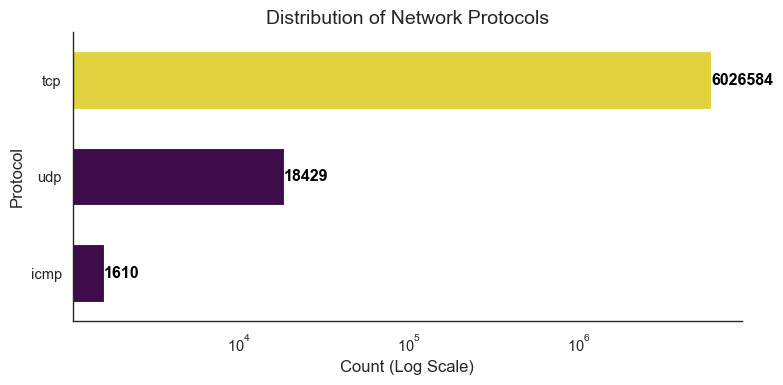

In [9]:
protocol_counts = df['protocol'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=protocol_counts.values, y=protocol_counts.index, width=0.6, hue=protocol_counts.values, palette='viridis', legend=False)
sns.despine(top=True, right=True)
plt.title('Distribution of Network Protocols', fontsize=14)
plt.xlabel('Count (Log Scale)', fontsize=12)
plt.ylabel('Protocol', fontsize=12)
plt.xscale('log')

for i, v in enumerate(protocol_counts.values):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/protocol_bar_chart.pdf', dpi=300, bbox_inches='tight')
plt.show()

Plot label frequencies

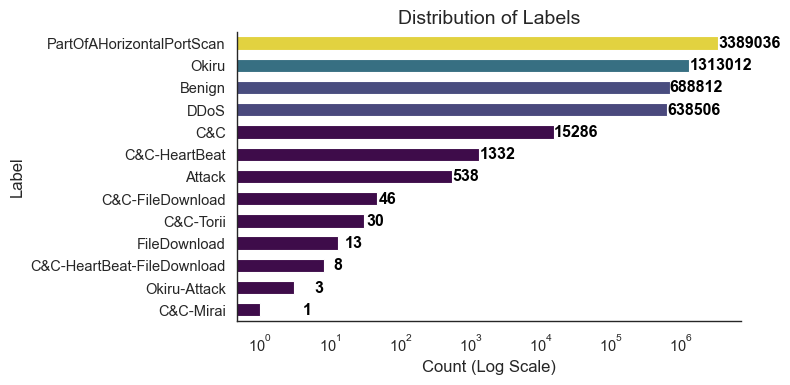

In [10]:
label_counts = df['label'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=label_counts.values,
            y=label_counts.index,
            width=0.6,
            hue=label_counts.values,
            palette='viridis',
            legend=False)
sns.despine(top=True, right=True)
plt.title('Distribution of Labels', fontsize=14)
plt.xlabel('Count (Log Scale)', fontsize=12)
plt.ylabel('Label', fontsize=12)
plt.xscale('log')

for i, v in enumerate(label_counts.values):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/label_bar_chart.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 4. Data Preparation

Convert labels into boolean values. True for attack, False for benign.

In [11]:
df['is_attack'] = np.where(df['label'] == 'Benign', 0, 1).astype(bool)
df = df.drop(columns=['label'])
df['is_attack'].value_counts()

is_attack
True     5357811
False     688812
Name: count, dtype: int64

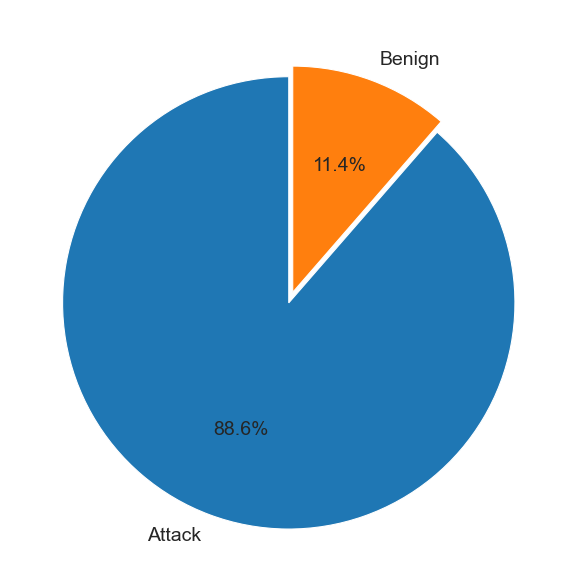

In [12]:
plt.figure(figsize=(6, 6))
plt.pie(
    df['is_attack'].value_counts(),
    labels=['Attack', 'Benign'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 14},
    explode=(0.05, 0)
)

plt.tight_layout()
plt.savefig('graphs/attack_benign_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
print(df.dtypes)

timestamp                         float64
source_port                       float64
dest_port                         float64
protocol                              str
service                               str
duration                              str
payload_bytes_sent_from_source        str
payload_bytes_sent_from_dest          str
connection_state                      str
missed_bytes                      float64
packets_sent_from_source          float64
ip_bytes_sent_from_source         float64
packets_sent_from_dest            float64
ip_bytes_sent_from_dest           float64
is_attack                            bool
dtype: object


Change data types of features

In [14]:
# List the columns that should be numbers but are currently 'str'
numeric_cols = [
    'duration',
    'payload_bytes_sent_from_source',
    'payload_bytes_sent_from_dest'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill the new NaNs with 0
df[numeric_cols] = df[numeric_cols].fillna(0)

In [15]:
# List of columns that should be whole numbers
int_cols = [
    'source_port', 'dest_port', 'missed_bytes',
    'packets_sent_from_source', 'packets_sent_from_dest',
    'payload_bytes_sent_from_source', 'payload_bytes_sent_from_dest',
    'ip_bytes_sent_from_source', 'ip_bytes_sent_from_dest'
]

df[int_cols] = df[int_cols].astype('Int64')

In [16]:
# List of columns that should be categorical
cat_cols = ['protocol', 'service', 'connection_state']

for col in cat_cols:
    df[col] = df[col].astype('category')

One-hot encode catagorical features

In [17]:
# Select the categorical columns
categorical_cols = ['protocol', 'service', 'connection_state']

# This will transform them into multiple 0/1 columns
df = pd.get_dummies(df, columns=categorical_cols)

In [18]:
# Replace any remaining hidden inf values with 0
df = df.replace([np.inf, -np.inf], 0)

# Fill any remaining NaNs with 0
df = df.fillna(0)

## 4. Feature Engineering

Create Inter-Arrival-Time (IAT) feature

In [19]:
df["inter_arrival_time"] = df["timestamp"].diff().fillna(0)
df.drop(columns=["timestamp"], inplace=True)
df.head()

,source_port,dest_port,duration,payload_bytes_sent_from_source,payload_bytes_sent_from_dest,missed_bytes,packets_sent_from_source,ip_bytes_sent_from_source,packets_sent_from_dest,ip_bytes_sent_from_dest,...,connection_state_RSTR,connection_state_RSTRH,connection_state_S0,connection_state_S1,connection_state_S2,connection_state_S3,connection_state_SF,connection_state_SH,connection_state_SHR,inter_arrival_time
0,17576,8081,0.000003,0,0,0,2,80,0,0,...,False,False,True,False,False,False,False,False,False,0.000000
1,17576,8081,0.000002,0,0,0,2,80,0,0,...,False,False,True,False,False,False,False,False,False,0.000005
2,17576,8081,0.000002,0,0,0,2,80,0,0,...,False,False,True,False,False,False,False,False,False,0.000004
3,17576,8081,0.000002,0,0,0,2,80,0,0,...,False,False,True,False,False,False,False,False,False,0.000012
4,17576,8081,0.000002,0,0,0,2,80,0,0,...,False,False,True,False,False,False,False,False,False,0.000004


Create avg packet size features

In [20]:
df['avg_packet_size_source'] = (df['ip_bytes_sent_from_source'] / df['packets_sent_from_source']).replace([np.inf, -np.inf], 0).fillna(0)
df['avg_packet_size_dest'] = (df['ip_bytes_sent_from_dest'] / df['packets_sent_from_dest']).replace([np.inf, -np.inf], 0).fillna(0)

Create throughput feature

In [21]:
df['throughput'] = (df['ip_bytes_sent_from_source'] / df['duration']).replace([np.inf, -np.inf], 0).fillna(0)

Create packet ratio feature

In [22]:
df['packet_ratio'] = (df['packets_sent_from_source'] / df['packets_sent_from_dest']).replace([np.inf, -np.inf], 0).fillna(0)

Create byte ratio feature

In [23]:
df['byte_ratio'] = (df['payload_bytes_sent_from_source'] / df['payload_bytes_sent_from_dest']).replace([np.inf, -np.inf], 0).fillna(0)

List minimum and maximum values of features to be used in the traffic generator script

In [31]:
# Define the features needed and the label for ground truth
export_features = [
    'source_port',
    'dest_port',
    'ip_bytes_sent_from_source',
    'inter_arrival_time',
    'is_attack'
]

# Extract 100 random samples of each class
benign_samples = df[df['is_attack'] == 0].sample(100, random_state=42)
attack_samples = df[df['is_attack'] == 1].sample(100, random_state=42)

# Combine and shuffle so the ESP32 doesn't just see 100 benign followed by 100 attacks
test_set = pd.concat([benign_samples, attack_samples]).sample(frac=1, random_state=42)

# Export to CSV
test_set[export_features].to_csv('data/esp32_test_data.csv', index=False)

print("Exported 200 samples to esp32_test_data.csv")

Exported 200 samples to esp32_test_data.csv


## 5. Split Data

Split the data into training and test tests

In [ ]:
X = df.drop(columns=['is_attack'])
y = df['is_attack']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 5. Scaling

Scale values

In [ ]:
# Scale, fit on training data only
scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

## 6. Balancing

Downsample the training dataset to 100,000 samples.

In [ ]:
# Create train_df using the already-scaled DataFrame
train_df = X_train_scaled.copy()
train_df['is_attack'] = y_train.values

df_attack = train_df[train_df['is_attack'] == 1].sample(n=50000, replace=True, random_state=42)
df_normal = train_df[train_df['is_attack'] == 0].sample(n=50000, replace=True, random_state=42)
df_scaled_balanced = pd.concat([df_attack, df_normal]).sample(frac=1, random_state=42)

X_train_final = df_scaled_balanced.drop(columns=['is_attack'])
y_train_final = df_scaled_balanced['is_attack']

## 7. Training

Train base model

In [ ]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train_final, y_train_final)

## 8. Evaluation

In [ ]:
print(f"Number of features: {len(X.columns)}")
print("-" * 30)
for i, name in enumerate(X.columns, 1):
    print(f"{i}. {name}")

Evaluate the base model

In [ ]:
y_pred = rf_base.predict(X_test_scaled)
print("--- Base RF Model Classification Report ---")
print(classification_report(y_test, y_pred))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Benign', 'Attack'],
    cmap='Greens',
    values_format='d',
    ax=ax,
    text_kw={'fontsize': 16, 'fontweight': 'bold'},
)

ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=14, fontweight='bold')

ax.tick_params(axis='both', which='major', labelsize=12)

plt.title("Confusion Matrix: Base Model Random Forest\n(Trees = 100, Depth = Unconstrained", fontsize=14, pad=20)
plt.savefig('graphs/base_model_confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_base.feature_importances_
})

# MDI importance plot
top_10_mdi = feature_importance.sort_values('importance', ascending=False).reset_index(drop=True).head(10)

plt.figure(figsize=(10, 6))
ax1 = sns.barplot(
    data=top_10_mdi,
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
sns.despine()

for i, v in enumerate(top_10_mdi['importance']):
    ax1.text(v + (top_10_mdi['importance'].max() * 0.01), i, f'{v:.4f}',
             va='center', fontweight='semibold')

ax1.set_xlabel('Importance Score', fontsize=14, fontweight='bold')
ax1.set_ylabel('Feature Name', fontsize=14, fontweight='bold')

ax1.tick_params(axis='both', which='major', labelsize=12)

plt.title("Top 10 Features: Gini Importance (MDI)", fontsize=14, pad=20)
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.xlim(0, top_10_mdi['importance'].max() * 1.15)

plt.tight_layout()
plt.savefig('graphs/feature_importance_mdi.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Permutation Importance Plot (More Reliable)
print("Calculating Permutation Importance")

# Sample 50k rows from the test set for speed
X_test_sample = X_test_scaled.sample(n=50000, random_state=42)
y_test_sample = y_test.iloc[X_test_sample.index]

perm = permutation_importance(
    rf_base, X_test_sample, y_test_sample,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

top_10_perm = perm_importance.head(10)

plt.figure(figsize=(10, 6))
ax2 = sns.barplot(
    data=top_10_perm,
    x='importance',
    y='feature',
    hue='feature',
    palette='magma',
    legend=False
)
sns.despine()

for i, v in enumerate(top_10_perm['importance']):
    ax2.text(v + (top_10_perm['importance'].max() * 0.01), i, f'{v:.4f}',
             va='center', fontweight='semibold')

ax.set_xlabel('Mean Accuracy Decrease', fontsize=14, fontweight='bold')
ax.set_ylabel('Feature Name', fontsize=14, fontweight='bold')

ax.tick_params(axis='both', which='major', labelsize=12)

plt.title("Top 10 Features: Permutation Importance", fontsize=14, pad=20)
plt.xlabel("Mean Accuracy Decrease")
plt.ylabel("Feature Name")
plt.xlim(0, top_10_perm['importance'].max() * 1.15)

plt.tight_layout()
plt.savefig('graphs/feature_importance_permutation.pdf', bbox_inches='tight')
plt.show()

print("\nMeaningful Features (Permutation > 0.001):")
meaningful_features = perm_importance[perm_importance['importance'] > 0.001]
print(meaningful_features['feature'].tolist())

Select the top features

In [ ]:
# Create dataframe containing only meaningful features
X_meaningful = X[meaningful_features['feature'].tolist()]
X_meaningful.head()

In [ ]:
# Split the raw meaningful features
X_train_meaningful, X_test_meaningful, y_train_meaningful, y_test_meaningful = train_test_split(
    X_meaningful, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Combine the features and the target into one dataframe
edge_impulse_data = X_train_meaningful.copy()
edge_impulse_data['target_class'] = y_train.values

# Save to CSV
edge_impulse_data.to_csv('data/ids_balanced_5feature_data.csv', index=False)

In [ ]:
# Scale
scaler_meaningful = RobustScaler()

X_train_m_scaled_df = pd.DataFrame(
    scaler_meaningful.fit_transform(X_train_meaningful),
    columns=X_train_meaningful.columns
)

X_test_m_scaled_df = pd.DataFrame(
    scaler_meaningful.transform(X_test_meaningful),
    columns=X_test_meaningful.columns
)

# Balance
train_m_df = X_train_m_scaled_df.copy()
train_m_df['is_attack'] = y_train_meaningful.values

df_m_attack = train_m_df[train_m_df['is_attack'] == 1].sample(n=50000, replace=True, random_state=42)
df_m_normal = train_m_df[train_m_df['is_attack'] == 0].sample(n=50000, replace=True, random_state=42)
df_m_balanced = pd.concat([df_m_attack, df_m_normal]).sample(frac=1, random_state=42)

# Final Training Features and Labels
X_train_meaningful_final = df_m_balanced.drop(columns=['is_attack'])
y_train_meaningful_final = df_m_balanced['is_attack']

# Train the 5-Feature Model
rf_meaningful = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_meaningful.fit(X_train_meaningful_final, y_train_meaningful_final)

# Evaluate on the original (imbalanced) scaled test set
y_pred_meaningful = rf_meaningful.predict(X_test_m_scaled_df)

print("--- 5-Feature Performance (Optimised Model) ---")
print(classification_report(y_test_meaningful.values, y_pred_meaningful))

Even with only five features, reduced down from thirty-nine. The model still performs well with perfect scores.

Plot confusion matrix for the RF model using only the five most important features

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_meaningful,
    y_pred_meaningful,
    display_labels=['Benign', 'Attack'],
    cmap='Blues',
    values_format='d',
    ax=ax,
    text_kw={'fontsize': 16, 'fontweight': 'bold'}
)

ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=14, fontweight='bold')

ax.tick_params(axis='both', which='major', labelsize=12)

plt.title("Confusion Matrix: 5-Feature Random Forest", fontsize=14, pad=20)
plt.savefig('graphs/five_feature_confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Base Model Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test.values,
    y_pred, # This is from your rf_base
    display_labels=['Benign', 'Attack'],
    cmap='Greens',
    ax=ax1,
    values_format='d'
)
ax1.set_title("Base Model (All Features)", fontsize=14, pad=20)

ax1.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=14, fontweight='bold')

ax1.tick_params(axis='both', which='major', labelsize=12)

# 2. 5-Feature Model Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_meaningful.values,
    y_pred_meaningful, # This is from your rf_meaningful
    display_labels=['Benign', 'Attack'],
    cmap='Blues',
    ax=ax2,
    values_format='d',
    text_kw={'fontsize': 16, 'fontweight': 'bold'}
)
ax2.set_title("5-Feature Model", fontsize=14, pad=20)

ax2.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=14, fontweight='bold')

ax2.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('graphs/model_comparison_matrices.pdf')
plt.show()

Save the model

In [ ]:
# Save the model and scaler
joblib.dump(rf_meaningful, 'models/random_forest_iot23.joblib')
joblib.dump(scaler_meaningful, 'models/scaler_iot23.joblib')

# Check file size in KB
size_kb = os.path.getsize('models/random_forest_iot23.joblib') / 1024
print(f"Random Forest Model Size: {size_kb:.2f} KB")

## 9. Optimisation

Currently, the model size is ~2800KB. This is too large for the ESP32 512KB RAM.

In [ ]:
print(f"{'Trees':<6} | {'Depth':<6} | {'Accuracy':<10} | {'F1-Score':<10} | {'C++ Lines':<10}")
print("-" * 55)

for trees in [5, 10]:
    for depth in [3, 5, 7, 10, 12, 15, 20]:
        test_rf = RandomForestClassifier(n_estimators=trees, max_depth=depth, random_state=42, n_jobs=-1)
        test_rf.fit(X_train_meaningful_final, y_train_meaningful_final)

        preds = test_rf.predict(X_test_m_scaled_df)
        acc = test_rf.score(X_test_m_scaled_df, y_test_meaningful)
        f1 = f1_score(y_test_meaningful, preds)

        # Export to C code
        temp_code = m2c.export_to_c(test_rf)
        lines = len(temp_code.split('\n'))

        print(f"{trees:<6} | {depth:<6} | {acc:<10.4f} | {f1:<10.4f} | {lines:<10}")

Using five trees actually produces better accuracy and F1-scores compared to ten trees, while also remaining smaller in memory (C++ Lines).
The combination of five trees and a depth of 15 appears best. It provides the highest accuracy and joint-highest f1 across the board.

In [ ]:
# Create the model with the optimised parameters (5 trees, 15 depth)
rf_optimised = RandomForestClassifier(n_estimators=5, max_depth=15, random_state=42)

# Create the pipeline for Cross-Validation
cv_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('rf', RandomForestClassifier(n_estimators=5, max_depth=15, random_state=42))
])

# Perform Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X_train_meaningful, y_train_meaningful, cv=kf)

print("--- Cross-Validation Results ---")
print(f"Individual Fold Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Stability (Std Dev): {cv_scores.std():.4f}")

# Overfitting Check (Train vs Test)
rf_optimised.fit(X_train_meaningful_final, y_train_meaningful_final)

train_acc = rf_optimised.score(X_train_meaningful_final, y_train_meaningful_final)
test_acc = rf_optimised.score(X_test_m_scaled_df, y_test_meaningful)

print("\n--- Generalisation Check ---")
print(f"Training Accuracy (Balanced): {train_acc*100:.2f}%")
print(f"Testing Accuracy (Imbalanced): {test_acc*100:.2f}%")
print(f"The 'Gap': {(train_acc - test_acc)*100:.4f}%")

if (train_acc - test_acc) > 0.05:
    print("WARNING: Model may be overfitting (Gap > 5%)")
else:
    print("SUCCESS: Model generalizes well to unseen data.")

# Check Size
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(rf_optimised, 'models/rf_optimised.joblib')
optimised_size_kb = os.path.getsize('models/rf_optimised.joblib') / 1024
print(f"\nPC Model Size (Joblib): {optimised_size_kb:.2f} KB")

In [ ]:
y_pred_optimised = rf_optimised.predict(X_test_m_scaled_df)

print("--- Optimised RF (5 Trees, Depth 15) Performance ---")
print(classification_report(y_test_meaningful.values, y_pred_optimised))

# Plot the final confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_meaningful.values,
    y_pred_optimised,
    display_labels=['Benign', 'Attack'],
    cmap='Reds',
    values_format='d',
    ax=ax,
    text_kw={'fontsize': 16, 'fontweight': 'bold'}
)

ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=14, fontweight='bold')

ax.tick_params(axis='both', which='major', labelsize=12)

plt.title(f"Confusion Matrix: Optimised RF Model\n(Trees = 5, Depth = 15", fontsize=14, pad=20)
plt.savefig('graphs/optimised_confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Create a 3-column grid for side-by-side comparison
fig, axes = plt.subplots(3, 1, figsize=(8, 16))

# Base Model (Full 39 Features)
y_pred_base = rf_base.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(
    y_test.values,
    y_pred_base,
    display_labels=['Benign', 'Attack'],
    cmap='Greens',
    values_format='d',
    ax=axes[0],
    text_kw={'fontsize': 16, 'fontweight': 'bold'}
)
axes[0].set_title("1. Base Model\n(20+ Features, Unconstrained PC)", fontsize=14, pad=20)

axes[0].set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=14, fontweight='bold')

axes[0].tick_params(axis='both', which='major', labelsize=12)


# Meaningful Model (5 Features, Unoptimised)
y_pred_m = rf_meaningful.predict(X_test_m_scaled_df)
ConfusionMatrixDisplay.from_predictions(
    y_test_meaningful.values,
    y_pred_m,
    display_labels=['Benign', 'Attack'],
    cmap='Blues',
    values_format='d',
    ax=axes[1],
    text_kw={'fontsize': 16, 'fontweight': 'bold'}
)
axes[1].set_title("2. Meaningful Model\n(5 Features, 100 Trees)", fontsize=14, pad=20)

axes[1].set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=14, fontweight='bold')

axes[1].tick_params(axis='both', which='major', labelsize=12)

# Final Optimised Model (5 Features, 5 Trees, 15 Depth)
y_pred_opt = rf_optimised.predict(X_test_m_scaled_df)
ConfusionMatrixDisplay.from_predictions(
    y_test_meaningful.values,
    y_pred_opt,
    display_labels=['Benign', 'Attack'],
    cmap='Reds',
    values_format='d',
    ax=axes[2],
    text_kw={'fontsize': 16, 'fontweight': 'bold'}
)
axes[2].set_title(f"3. Final Optimised Model\n(5 Features, 5 Trees, 15 Depth)", fontsize=14, pad=20)

axes[2].set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
axes[2].set_ylabel('True Label', fontsize=14, fontweight='bold')

axes[2].tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('graphs/complete_model_comparison_matrices.pdf', bbox_inches='tight')
plt.show()

## 10. Exportation

In [ ]:
# Capture Scaler Parameters used for C++ implementation
print("--- SCALER PARAMETERS for ESP32 ---")
feature_list = X_train_meaningful.columns.tolist()

for i, feature in enumerate(feature_list):
    print(f"Feature: {feature}")
    print(f"  Median (Center): {scaler_meaningful.center_[i]:.8f}")
    print(f"  IQR (Scale):     {scaler_meaningful.scale_[i]:.8f}")
    print("-" * 30)

Convert to c++

In [ ]:
# Export Model to C++
code = m2c.export_to_c(rf_optimised)
if not os.path.exists('models'): os.makedirs('models')
with open("models/optimised_rf_model.h", "w") as f:
    f.write(code)
print("C++ Header File Generated: models/optimised_rf_model.h\n")

Convert unscaled test samples to C++ so scaling and inference can be tested

In [ ]:
# Separate the classes in the test set
test_attacks = X_test_meaningful[y_test_meaningful == 1]
test_benign = X_test_meaningful[y_test_meaningful == 0]

# Take 250 of each to make a balanced 1000-sample set
balanced_X_test = pd.concat([test_attacks.head(2500), test_benign.head(2500)])
balanced_y_test = pd.concat([y_test_meaningful[y_test_meaningful == 1].head(2500),
                             y_test_meaningful[y_test_meaningful == 0].head(2500)])

# Shuffle them so they aren't all Attacks first, then all Benign
X_final, y_final = shuffle(balanced_X_test, balanced_y_test, random_state=42)

# Print for C++
print(f"double raw_samples[5000][5] = {{")
for row in X_final.values:
    print("  {" + ", ".join(map(str, row)) + "},")
print("};\n")

print(f"int true_labels[5000] = {{")
print("  " + ", ".join(map(str, y_final.values.astype(int))))
print("};")

## 11. Visualisation

Plot one of the trees

In [ ]:
# Visualise the Decision Tree Logic
plt.figure(figsize=(16, 8))
plot_tree(rf_optimised.estimators_[0],
          feature_names=feature_list,
          class_names=['Benign', 'Attack'],
          filled=True,
          rounded=True,
          fontsize=12,
          max_depth=2)
plt.title("Decision Path: Optimised Tree Structure (Visualised to Depth 3)")
plt.savefig("graphs/decision_tree_logic.pdf", bbox_inches='tight')
plt.show()